In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import re

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, ttest_ind, spearmanr

sns.set_context("paper", font_scale=1.2)
plt.style.use('ggplot')
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18, 
    "axes.labelsize": 16, 
    "xtick.labelsize": 16, 
    "ytick.labelsize": 16, 
    "figure.dpi": 300
})

## Tumor vs normal (ccRCC)

### Load and process data

In [2]:
ann_data = sc.read_h5ad('../data/validation_data/rnaseq/PD45816_6800STDY12499506_I2.annotated.h5ad')
tca_status = pd.read_csv("../data/validation_data/spatial/tca_count_validation.csv", index_col=0)
flux_data = pd.read_csv("../data/validation_data/spatial/flux_mean_validation.csv", index_col=0)

In [10]:
tca_status.head(3)

,c_propensity,nc_propensity,both active,biomass mean c,biomass mean nc,biomass mean b,c_flux_intensity,nc_flux_intensity
Cell_lines,,,,,,,,
6800STDY12499506_AAACACCAATAACTGC-1,0.0801,0.3205,115,1.328177,1.110354,1.482942,6.916968,85.562352
6800STDY12499506_AAACAGAGCGACTCCT-1,0.0613,0.4066,201,3.946299,3.909048,4.025022,25.330806,211.482465
6800STDY12499506_AAACATGGTGAGAGGA-1,0.0599,0.3870,127,0.946200,1.459495,1.343680,16.178475,114.559241


In [40]:
flux_data.head(3)

,EX_lac__L_e,EX_glc__D_e,EX_glu__L_e,EX_gln__L_e,EX_asp__L_e,EX_co2_e,EX_h_e,EX_h2o_e,EX_pi_e,EX_nh4_e,...,t_Lcystin_glu__L,t_Lcystin_leu__L,t_Lcystin_ser__L,CSNATr,CRNCARtm,CSNATm,ACS,ACt2m,PyrODC,Incompox_Pyr
Cell_lines,,,,,,,,,,,,,,,,,,,,,
6800STDY12499506_AAACACCAATAACTGC-1,160.987490,-70.476031,-41.849296,-128.771632,-5.936132,664.856286,139.121402,-258.125934,-1.364265,753.205638,...,0.000000,22.343768,20.851855,-27.894488,-27.894488,-27.894488,20.064143,-20.064143,0.143626,19.920517
6800STDY12499506_AAACAGAGCGACTCCT-1,334.795154,-223.000609,-265.730916,-91.481557,1.508711,926.000654,332.378014,-38.846228,-3.607195,836.690207,...,18.206098,77.792682,66.437219,100.601956,100.601956,100.601956,63.798743,-63.798743,0.226904,63.571840
6800STDY12499506_AAACATGGTGAGAGGA-1,160.058096,-85.647345,-30.072645,-167.554898,15.519116,726.149569,194.119729,-290.186585,-1.775915,776.893248,...,0.000000,17.560310,17.383163,1.238986,1.238986,1.238986,36.856813,-36.856813,0.196590,36.660223


In [91]:
trasc_data.obs

,in_tissue,array_row,array_col,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,mt_frac,donor_id,region,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,leiden
spot_id,,,,,,,,,,,,,,,,,,,
6800STDY12499506_AAACACCAATAACTGC-1,1,59,19,6800STDY12499506,1205,7.095064,2053.0,7.627544,23.964929,34.145153,45.737944,65.660010,0.047735,PD45816,g,98.0,4.595120,4.773502,0
6800STDY12499506_AAACAGAGCGACTCCT-1,1,14,94,6800STDY12499506,2722,7.909489,7465.0,8.918115,30.663094,40.174146,50.783657,64.661755,0.129538,PD45816,g,967.0,6.875232,12.953785,1
6800STDY12499506_AAACATGGTGAGAGGA-1,1,62,0,6800STDY12499506,1604,7.380879,2831.0,7.948739,22.677499,32.038149,43.482868,61.003179,0.082656,PD45816,g,234.0,5.459586,8.265630,0
6800STDY12499506_AAACCGTTCGTCCAGG-1,1,52,42,6800STDY12499506,2029,7.615791,3921.0,8.274357,19.892884,29.966845,41.162969,58.760520,0.035960,PD45816,g,141.0,4.955827,3.596022,0
6800STDY12499506_AAACGAAGAACATACC-1,1,6,64,6800STDY12499506,3176,8.063693,9386.0,9.147081,31.131472,39.420413,49.051779,62.518645,0.137545,PD45816,g,1291.0,7.163947,13.754529,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6800STDY12499506_TTGTTCAGTGTGCTAC-1,1,24,64,6800STDY12499506,2481,7.816820,6213.0,8.734560,30.983422,39.175921,49.058426,63.415419,0.163045,PD45816,g,1013.0,6.921658,16.304523,1
6800STDY12499506_TTGTTGTGTGTCAAGA-1,1,31,77,6800STDY12499506,2115,7.657283,4596.0,8.433159,27.175805,36.401218,46.953873,62.663185,0.115970,PD45816,g,533.0,6.280396,11.597041,2
6800STDY12499506_TTGTTTCACATCCAGG-1,1,58,42,6800STDY12499506,1768,7.478170,3098.0,8.038835,20.142027,29.857973,40.994190,59.070368,0.026146,PD45816,g,81.0,4.406719,2.614590,0


In [97]:
ann_data.obs

,in_tissue,array_row,array_col,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,mt_frac,donor_id,region,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,leiden,x,y,region_annotation
spot_id,,,,,,,,,,,,,,,,,,,,,
6800STDY12499506_AAACACCAATAACTGC-1,1,59,19,6800STDY12499506,1205,7.095064,2053.0,7.627544,23.964929,34.145153,...,0.047735,PD45816,g,98.0,4.595120,4.773502,0,2175,7101,Renal parenchyma
6800STDY12499506_AAACAGAGCGACTCCT-1,1,14,94,6800STDY12499506,2722,7.909489,7465.0,8.918115,30.663094,40.174146,...,0.129538,PD45816,g,967.0,6.875232,12.953785,1,6421,2684,Tumor
6800STDY12499506_AAACATGGTGAGAGGA-1,1,62,0,6800STDY12499506,1604,7.380879,2831.0,7.948739,22.677499,32.038149,...,0.082656,PD45816,g,234.0,5.459586,8.265630,0,1101,7395,Renal parenchyma
6800STDY12499506_AAACCGTTCGTCCAGG-1,1,52,42,6800STDY12499506,2029,7.615791,3921.0,8.274357,19.892884,29.966845,...,0.035960,PD45816,g,141.0,4.955827,3.596022,0,3476,6415,Renal parenchyma
6800STDY12499506_AAACGAAGAACATACC-1,1,6,64,6800STDY12499506,3176,8.063693,9386.0,9.147081,31.131472,39.420413,...,0.137545,PD45816,g,1291.0,7.163947,13.754529,2,4727,1895,Tumor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6800STDY12499506_TTGTTCAGTGTGCTAC-1,1,24,64,6800STDY12499506,2481,7.816820,6213.0,8.734560,30.983422,39.175921,...,0.163045,PD45816,g,1013.0,6.921658,16.304523,1,4724,3664,Tumor
6800STDY12499506_TTGTTGTGTGTCAAGA-1,1,31,77,6800STDY12499506,2115,7.657283,4596.0,8.433159,27.175805,36.401218,...,0.115970,PD45816,g,533.0,6.280396,11.597041,2,5457,4354,Tumor
6800STDY12499506_TTGTTTCACATCCAGG-1,1,58,42,6800STDY12499506,1768,7.478170,3098.0,8.038835,20.142027,29.857973,...,0.026146,PD45816,g,81.0,4.406719,2.614590,0,3475,7005,Renal parenchyma


In [3]:
spot_ann = pd.DataFrame(index=ann_data.obs_names, 
                        data={"annotation": ann_data.obs['region_annotation']})

biomass_syn_flux = flux_data["Biomass"]

print(tca_status.shape, spot_ann.shape)
tca_status["region_annotation"] = spot_ann.loc[tca_status.index, "annotation"]
tca_status["biomass_syn_flux"] = biomass_syn_flux.loc[tca_status.index]
print(tca_status.shape)

(1777, 8) (1777, 1)
(1777, 10)


In [4]:
spot_ann.value_counts()

annotation      
Tumor               1245
Renal parenchyma     460
NA                    72
Name: count, dtype: int64

In [5]:
# filtre out unknown region (NA)

print("Before filter:", tca_status.shape)
tca_status = tca_status[tca_status["region_annotation"] != "NA"]
print("After filter:", tca_status.shape)

Before filter: (1777, 10)
After filter: (1705, 10)


### NC TCA

In [6]:
tca_status.columns

Index(['c_propensity', 'nc_propensity', 'both active', 'biomass mean c',
       'biomass mean nc', 'biomass mean b', 'c_flux_intensity',
       'nc_flux_intensity', 'region_annotation', 'biomass_syn_flux'],
      dtype='object')

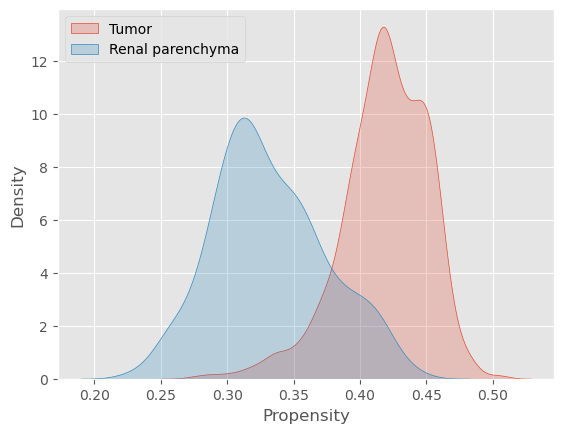

In [7]:
# Propensity comparison between tumor and renal parenchyma
sns.kdeplot(tca_status[tca_status["region_annotation"] == "Tumor"]["nc_propensity"], fill=True)
sns.kdeplot(tca_status[tca_status["region_annotation"] == "Renal parenchyma"]["nc_propensity"], fill=True)
plt.xlabel("Propensity")
plt.legend(["Tumor", "Renal parenchyma"])

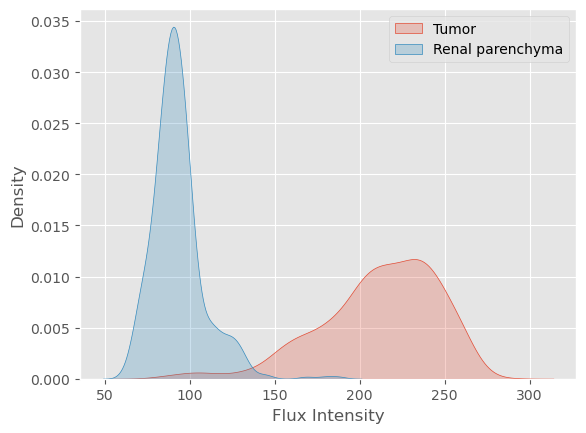

In [8]:
sns.kdeplot(tca_status[tca_status["region_annotation"] == "Tumor"]["nc_flux_intensity"], fill=True)
sns.kdeplot(tca_status[tca_status["region_annotation"] == "Renal parenchyma"]["nc_flux_intensity"], fill=True)
plt.xlabel("Flux Intensity")
plt.legend(["Tumor", "Renal parenchyma"])

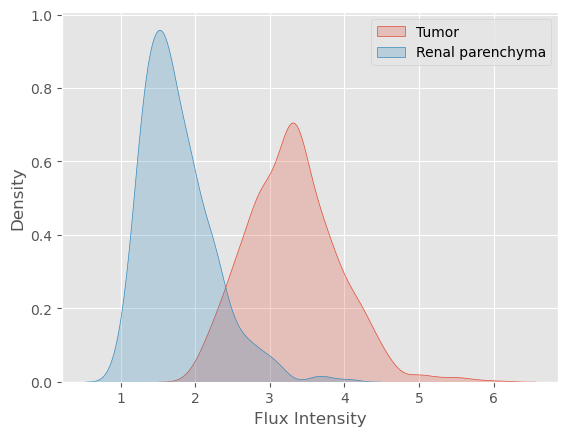

In [9]:
sns.kdeplot(tca_status[tca_status["region_annotation"] == "Tumor"]["biomass_syn_flux"], fill=True)
sns.kdeplot(tca_status[tca_status["region_annotation"] == "Renal parenchyma"]["biomass_syn_flux"], fill=True)
plt.xlabel("Flux Intensity")
plt.legend(["Tumor", "Renal parenchyma"])

In [7]:
tca_status["region_annotation"] = tca_status["region_annotation"].replace({
    "Renal parenchyma": "Normal"
})
order = ["Tumor", "Normal"]


C:\Users\LL331070\AppData\Local\Temp\ipykernel_16992\3412781279.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  tca_status["region_annotation"] = tca_status["region_annotation"].replace({


biomass_syn_flux - t-stat: 54.27, p = 6.9e-307
nc_propensity - t-stat: 39.61, p = 7.3e-178
nc_flux_intensity - t-stat: 96.30, p < 1e-308


C:\Users\LL331070\AppData\Local\Temp\ipykernel_16992\2920614012.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\LL331070\AppData\Local\Temp\ipykernel_16992\2920614012.py:28: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\LL331070\AppData\Local\Temp\ipykernel_16992\2920614012.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\LL331070\AppData\Local\Temp\ipykernel_16992\2920614012.py:28: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\U

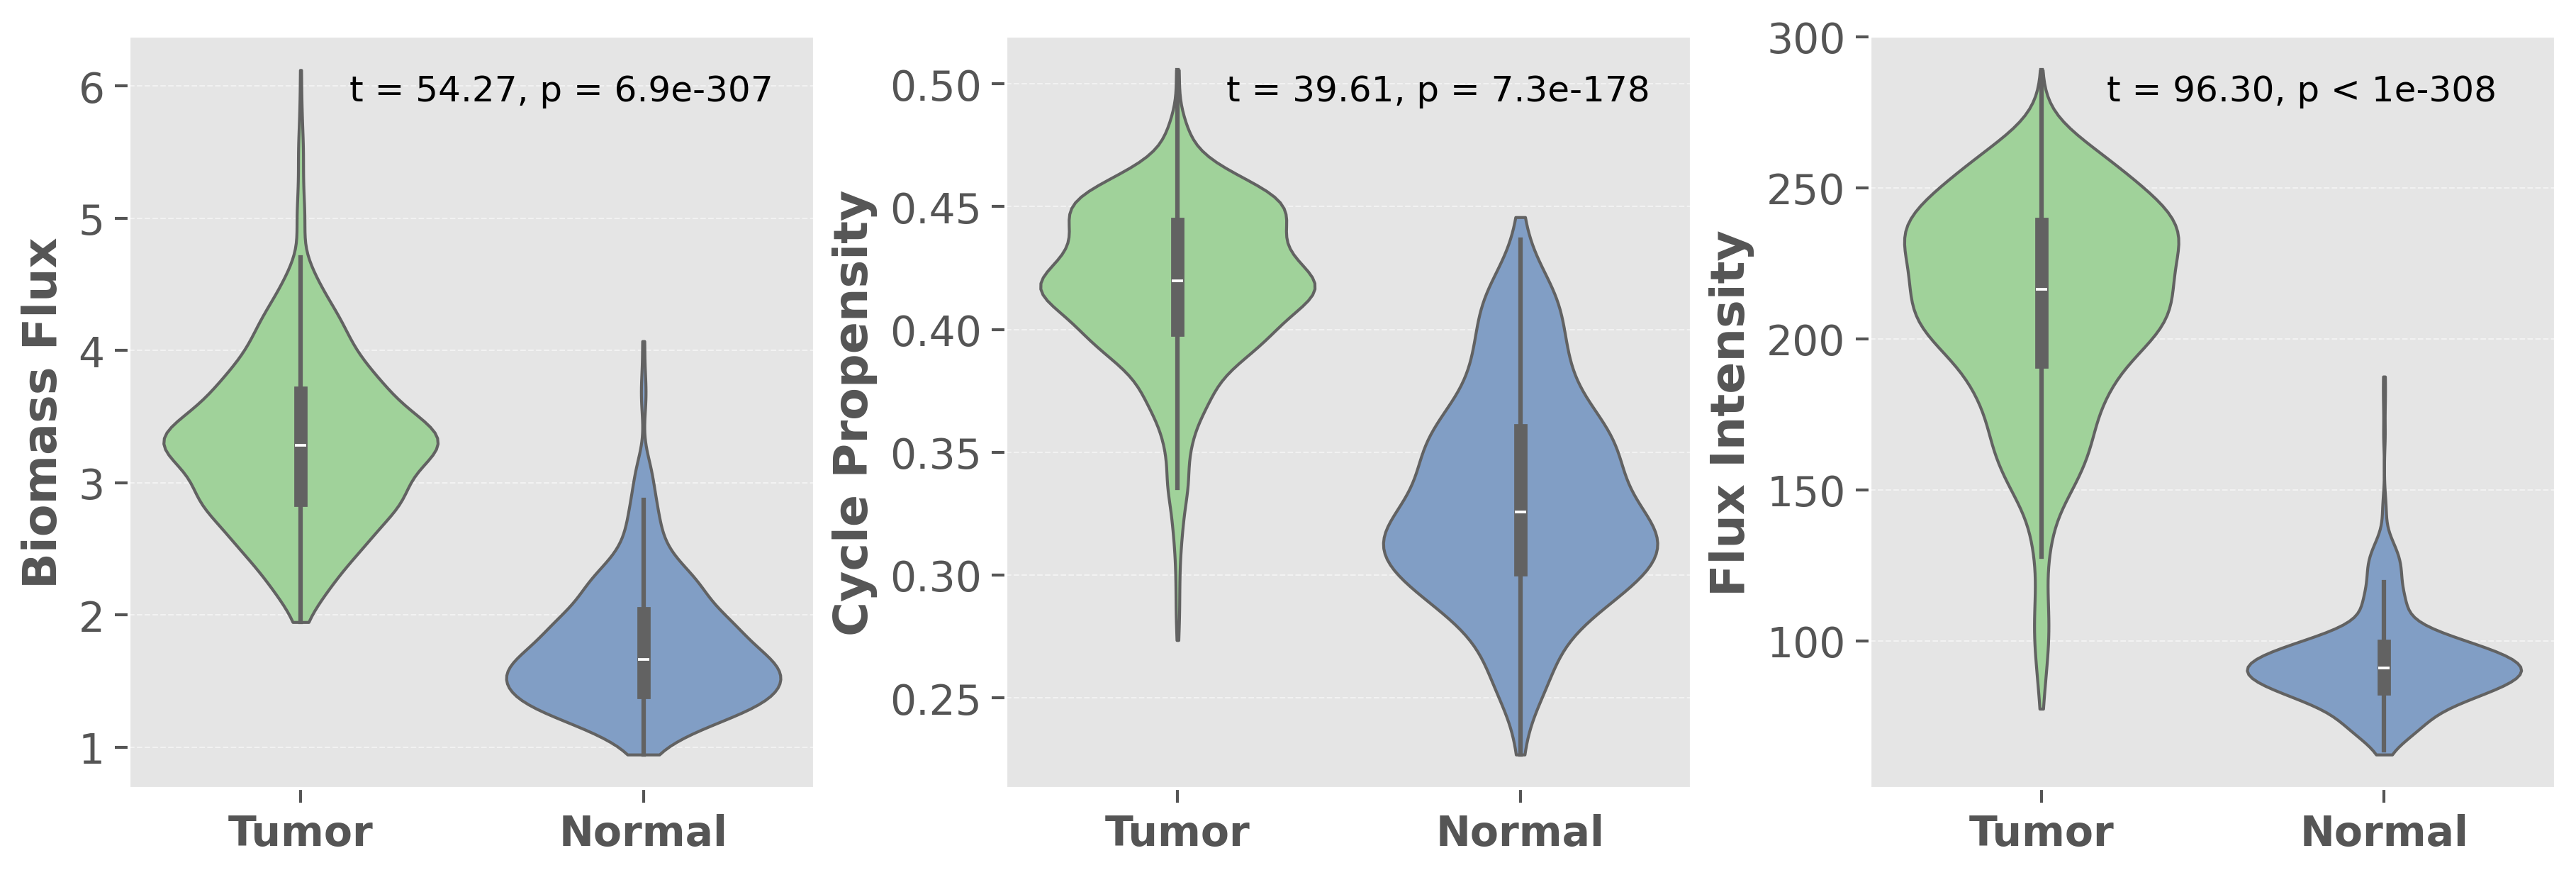

In [9]:
metrics = [
    ("biomass_syn_flux", "Biomass Flux"),
    ("nc_propensity", "Cycle Propensity"),
    ("nc_flux_intensity", "Flux Intensity"),
]

SAFE_MIN_P = 1e-308
def fmt_p(p):
    return "p < 1e-308" if np.isfinite(p) and p < SAFE_MIN_P else f"p = {p:.1e}"

sns.set_context("paper")
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

for ax, (col, ylab) in zip(axes, metrics):
    # Subset e dropna
    df_plot = tca_status.loc[
        tca_status["region_annotation"].isin(order), 
        ["region_annotation", col]
    ].dropna()

    # Welch’s t-test
    x1 = df_plot.loc[df_plot["region_annotation"] == order[0], col].values
    x2 = df_plot.loc[df_plot["region_annotation"] == order[1], col].values
    t_stat, p_val = ttest_ind(x1, x2, equal_var=False)
    print(f"{col} - t-stat: {t_stat:.2f}, {fmt_p(p_val)}")

    # Violin plot 
    sns.violinplot(
        data=df_plot,
        x="region_annotation",
        y=col,
        order=order,
        ax=ax,
        inner="box",
        cut=0,
        scale="width",
        palette={"Tumor": "#99db91", "Normal": "#769dd0"},
    )

    # Labeling
    ax.set_xlabel(None)
    ax.set_ylabel(ylab, fontsize=16, fontweight="bold")
    ax.tick_params(axis="y", labelsize=14)
    ax.tick_params(axis="x", labelsize=14)
    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

    # statistics annotation
    ax.text(
        0.63, 0.95, f"t = {t_stat:.2f}, {fmt_p(p_val)}",
        transform=ax.transAxes, ha="center", va="top", fontsize=12
    )

plt.savefig("../data/validation_data/spatial/plots/tca_metrics_tumor_vs_parenchyma.png",
            dpi=300, bbox_inches='tight')
plt.show()

## Proliferation signature for DEPMAP analysis

https://github.com/hbctraining/scRNA-seq

In [1]:
core_s_genes = [
    'ENSG00000012963','ENSG00000049541','ENSG00000051180','ENSG00000073111',
    'ENSG00000075131','ENSG00000076003','ENSG00000076248','ENSG00000077514',
    'ENSG00000092470','ENSG00000092853','ENSG00000093009','ENSG00000094804',
    'ENSG00000095002','ENSG00000100297','ENSG00000101868','ENSG00000104738',
    'ENSG00000111247','ENSG00000112312','ENSG00000117748','ENSG00000118412',
    'ENSG00000119969','ENSG00000129173','ENSG00000131153','ENSG00000132646',
    'ENSG00000132780','ENSG00000136492','ENSG00000136982','ENSG00000143476',
    'ENSG00000144354','ENSG00000151725','ENSG00000156802','ENSG00000159259',
    'ENSG00000162607','ENSG00000163950','ENSG00000167325','ENSG00000168496',
    'ENSG00000171848','ENSG00000174371','ENSG00000175305','ENSG00000176890',
    'ENSG00000197299','ENSG00000198056','ENSG00000276043'
]

core_g2m_genes = [
    'ENSG00000010292','ENSG00000011426','ENSG00000013810','ENSG00000072571',
    'ENSG00000075218','ENSG00000080986','ENSG00000087586','ENSG00000088325',
    'ENSG00000089685','ENSG00000092140','ENSG00000094916','ENSG00000100401',
    'ENSG00000102974','ENSG00000111665','ENSG00000112742','ENSG00000113810',
    'ENSG00000114346','ENSG00000115163','ENSG00000117399','ENSG00000117650',
    'ENSG00000117724','ENSG00000120802','ENSG00000123485','ENSG00000123975',
    'ENSG00000126787','ENSG00000129195','ENSG00000131747','ENSG00000134222',
    'ENSG00000134690','ENSG00000136108','ENSG00000137804','ENSG00000137807',
    'ENSG00000138160','ENSG00000138182','ENSG00000138778','ENSG00000139354',
    'ENSG00000142945','ENSG00000143228','ENSG00000143401','ENSG00000143815',
    'ENSG00000148773','ENSG00000157456','ENSG00000158402','ENSG00000164104',
    'ENSG00000169607','ENSG00000169679','ENSG00000170312','ENSG00000173207',
    'ENSG00000175063','ENSG00000175216','ENSG00000178999','ENSG00000184661',
    'ENSG00000188229','ENSG00000189159'
]

print(f"Loaded {len(core_s_genes)} S-phase and {len(core_g2m_genes)} G2/M genes.")

Loaded 43 S-phase and 54 G2/M genes.


In [52]:
y_path = "../data/features_label/tca_status_medium.csv"
tca_status_ccle = pd.read_csv(y_path, index_col=0)
tca_metrics_ccle = tca_status_ccle[["TCA non canonical", "activity TCA non canonical"]]

flux_data_ccle = pd.read_csv("../data/validation_data/ccle/cbs_mean_magic.csv", index_col=0)
biomass_ccle = flux_data_ccle["Biomass"]
print(tca_metrics_ccle.shape, biomass_ccle.shape)
tca_metrics_ccle = tca_metrics_ccle.merge(biomass_ccle, left_index=True, right_index=True)
print(tca_metrics_ccle.shape)

(513, 2) (513,)
(513, 3)


In [ ]:
adata = sc.read_h5ad("../data/features_label/raw_X/rna_seq_total") # raw expression data

In [ ]:
# Identify cell cycle genes in dataset
vset = pd.Index(adata.var_names.astype(str))
s_genes_use  = [g for g in core_s_genes if g in vset]
g2m_genes_use = [g for g in core_g2m_genes if g in vset]

missed_s = set(core_s_genes) - set(s_genes_use)
missed_g2m = set(core_g2m_genes) - set(g2m_genes_use)

print(f"Found {len(s_genes_use)} S-phase genes and {len(g2m_genes_use)} G2/M genes in dataset.")
if missed_s:
    print(f"Missed S-phase genes: {len(missed_s)} → {sorted(list(missed_s))[:5]} ...")
if missed_g2m:
    print(f"Missed G2/M genes: {len(missed_g2m)} → {sorted(list(missed_g2m))[:5]} ...")

Found 42 S-phase genes and 54 G2/M genes in dataset.
Missed S-phase genes: 1 → ['ENSG00000276043'] ...


In [ ]:
# compute proliferation score
sc.tl.score_genes(
    adata, gene_list=s_genes_use, score_name="S_score",
    use_raw=False, ctrl_size=len(s_genes_use), n_bins=25
)
sc.tl.score_genes(
    adata, gene_list=g2m_genes_use, score_name="G2M_score",
    use_raw=False, ctrl_size=len(g2m_genes_use), n_bins=25
)

adata.obs["Prolif_score"] = np.maximum(
    adata.obs["S_score"], adata.obs["G2M_score"]
)

tca_metrics_ccle["Proliferation_Score"] = adata.obs.loc[tca_metrics_ccle.index, "Prolif_score"]

In [56]:
tca_metrics_ccle.rename(columns={
    "TCA non canonical": "Propensity",
    "activity TCA non canonical": "Flux Intensity"
}, inplace=True)

In [ ]:
# tca_metrics_ccle.to_csv("../data/validation_data/ccle/tca_metrics_proliferation_ccle.csv")

#### Check correlation between proliferation sig and biomass flux

In [57]:
cols = tca_metrics_ccle.columns
n = len(cols)

corr_matrix = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)
pval_matrix = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)

# pairwise correlation
for i in range(n):
    for j in range(n):
        x = tca_metrics_ccle[cols[i]]
        y = tca_metrics_ccle[cols[j]]
        if x.isna().any() or y.isna().any():
            mask = x.notna() & y.notna()
            x, y = x[mask], y[mask]
        if len(x) > 1:
            r, p = pearsonr(x, y)
        else:
            r, p = np.nan, np.nan
        corr_matrix.iloc[i, j] = r
        pval_matrix.iloc[i, j] = p

corr_matrix = corr_matrix.round(3)
pval_matrix = pval_matrix.round(3)

corr_pval = corr_matrix.astype(str) + " (p=" + pval_matrix.astype(str) + ")"
corr_pval

,Propensity,Flux Intensity,Biomass,Proliferation_Score
Propensity,1.0 (p=0.0),-0.632 (p=0.0),0.023 (p=0.602),0.137 (p=0.002)
Flux Intensity,-0.632 (p=0.0),1.0 (p=0.0),-0.489 (p=0.0),-0.174 (p=0.0)
Biomass,0.023 (p=0.602),-0.489 (p=0.0),1.0 (p=0.0),0.284 (p=0.0)
Proliferation_Score,0.137 (p=0.002),-0.174 (p=0.0),0.284 (p=0.0),1.0 (p=0.0)


In [58]:
cols_check = ['Proliferation_Score']

df0 = tca_metrics_ccle.copy()

k = 3.0
bounds = {}
for c in cols_check:
    q1, q3 = df0[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    bounds[c] = (lo, hi)

mask_iqr = np.logical_and.reduce([
    (df0[c] >= bounds[c][0]) & (df0[c] <= bounds[c][1]) for c in cols_check
])

def mad(x):
    med = np.median(x)
    return np.median(np.abs(x - med))

mad_bounds = {}
mad_mask_parts = []
for c in cols_check:
    x = df0[c].to_numpy()
    med = np.median(x)
    mad_val = mad(x)
    rz = (x - med) / (1.4826 * mad_val if mad_val > 0 else np.inf)
    mad_mask_parts.append(np.abs(rz) <= 4)
mask_mad = np.logical_and.reduce(mad_mask_parts)

mask = mask_iqr & mask_mad   

tca_filt = df0[mask].copy()
print(f"Kept {tca_filt.shape[0]} / {df0.shape[0]} rows  (removed {df0.shape[0]-tca_filt.shape[0]})")


Kept 513 / 513 rows  (removed 0)


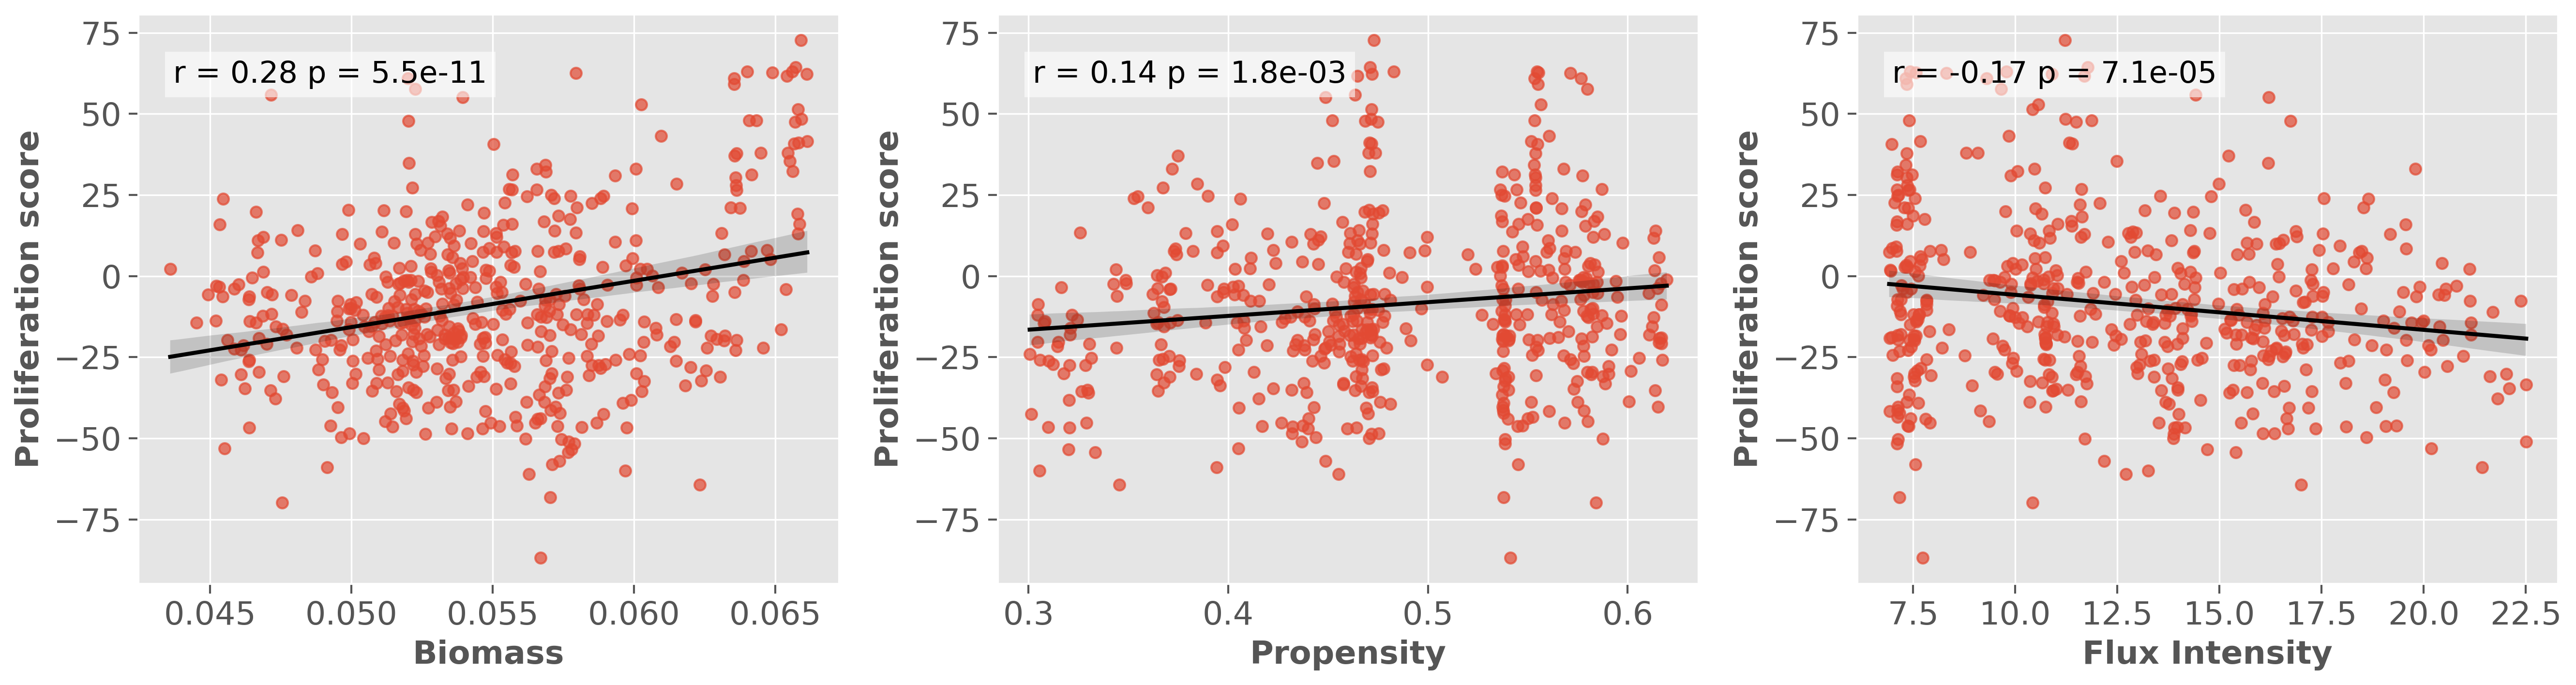

In [ ]:
xcols = ['Biomass', 'Propensity', 'Flux Intensity']
ycol = 'Proliferation_Score'

fig, axes = plt.subplots(1, 3, figsize=(18, 5), squeeze=False)
axes = axes.ravel()

for ax, xcol in zip(axes, xcols):
    dfp = tca_filt[[xcol, ycol]].dropna()
    x, y = dfp[xcol].values, dfp[ycol].values

    if len(dfp) > 1:
        r, p = pearsonr(x, y)
    else:
        r, p = np.nan, np.nan

    sns.regplot(
        x=xcol, y=ycol, data=dfp, ax=ax,
        scatter_kws=dict(s=30, alpha=0.7),
        line_kws=dict(lw=2, color='black')
    )

    def _pad(lo, hi, frac=0.05):
        span = hi - lo if hi > lo else 1.0
        pad = frac * span
        return lo - pad, hi + pad

    ax.set_xlim(*_pad(dfp[xcol].min(), dfp[xcol].max()))
    ax.set_ylim(*_pad(dfp[ycol].min(), dfp[ycol].max()))

    ax.set_xlabel(xcol, fontsize=16, fontweight='bold')
    ax.set_ylabel("Proliferation score", fontsize=16, fontweight='bold')

    text_x = 0.05 
    text_y = 0.92
    ax.text(
        text_x, text_y,
        f"r = {r:.2f} p = {p:.1e}",
        transform=ax.transAxes,
        fontsize=15,
        verticalalignment='top',
        horizontalalignment='left',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
    )

fig.tight_layout()
fig.savefig("../data/validation_data/ccle/plots/correlation_plots_magic_full.png",
            dpi=300, bbox_inches='tight')
plt.show()

## Warburg Effect

### Lactate production comparison


MDAMB231 VS MDAMB453 https://doi.org/10.1002/1873-3468.12360  
MDAMB231 VS MDAMB361 https://doi.org/10.1371/journal.pcbi.1009337

In [ ]:
flux = pd.read_csv("../data/validation_data/ccle/input/cbs_mean_magic.csv", index_col=0)
tca_metrics_ccle = pd.read_csv("../data/dependency_analysis/input_data/tca_metrics.csv", index_col=0)
trasc = sc.read_h5ad("../data/features_label/raw_X/rna_seq_total")
trasc_df = pd.DataFrame(trasc.X, index=trasc.obs_names, columns=trasc.var_names)

In [ ]:
flux.columns

Index(['EX_lac__L_e', 'EX_glc__D_e', 'EX_glu__L_e', 'EX_gln__L_e',
       'EX_asp__L_e', 'EX_co2_e', 'EX_h_e', 'EX_h2o_e', 'EX_pi_e', 'EX_nh4_e',
       ...
       't_Lcystin_glu__L', 't_Lcystin_leu__L', 't_Lcystin_ser__L', 'CSNATr',
       'CRNCARtm', 'CSNATm', 'ACS', 'ACt2m', 'PyrODC', 'Incompox_Pyr'],
      dtype='object', length=469)

In [ ]:
tca_metrics_ccle["Lac"] = flux["EX_lac__L_e"]
tca_metrics_ccle["Glc"] = flux["EX_glc__D_e"]
tca_metrics_ccle["O2"] = flux["EX_o2_e"]
tca_metrics_ccle["Lac/Glc"] = flux["EX_lac__L_e"] / - flux["EX_glc__D_e"]

In [18]:
tca_metrics_ccle

,Propensity,Flux Intensity,Lac,Glc,O2,Lac/Glc
22RV1_PROSTATE,0.3547,14.794442,4.733091,-8.532274,-37.870841,0.554728
2313287_STOMACH,0.3046,13.072795,4.482886,-8.540756,-42.558523,0.524882
5637_URINARY_TRACT,0.5422,12.879745,5.923773,-7.895253,-28.316971,0.750295
697_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,0.5623,10.430198,5.271437,-7.592021,-28.883210,0.694339
769P_KIDNEY,0.4553,17.514557,5.243026,-8.403162,-32.807222,0.623935
...,...,...,...,...,...,...
YD15_SALIVARY_GLAND,0.5833,11.371696,6.862131,-7.655923,-24.481331,0.896317
YD38_UPPER_AERODIGESTIVE_TRACT,0.5822,11.212096,6.806926,-7.652315,-24.719208,0.889525
YD8_UPPER_AERODIGESTIVE_TRACT,0.4779,13.736959,5.340489,-8.396589,-33.252632,0.636031
ZR751_BREAST,0.3653,10.843867,5.192226,-7.672868,-29.161022,0.676700


In [ ]:
# tca_metrics_ccle.to_csv("../data/validation_data/ccle/tca_metrics_ccle_lac_glc.csv")

In [5]:
tca_metrics_ccle_breast = tca_metrics_ccle[tca_metrics_ccle.index.str.contains("BREAST")]
# tca_metrics_ccle_breast.to_csv("../data/validation_data/ccle/tca_metrics_breast_cancer_ratio.csv")

In [ ]:
print(f"{tca_metrics_ccle_breast[tca_metrics_ccle_breast.index.str.contains('231')]}") 
print(f"{tca_metrics_ccle_breast[tca_metrics_ccle_breast.index.str.contains('453')]}")
print(f"{tca_metrics_ccle_breast[tca_metrics_ccle_breast.index.str.contains('361')]}")

                 Propensity  Flux Intensity       Lac       Glc   Lac/Glc  \
MDAMB231_BREAST      0.4579       15.731429  5.607461 -8.151599  0.687897   

                        O2  
MDAMB231_BREAST -30.750255  
                 Propensity  Flux Intensity       Lac       Glc  Lac/Glc  \
MDAMB453_BREAST      0.3673       10.738095  5.167219 -7.677084  0.67307   

                        O2  
MDAMB453_BREAST -29.261087  
                 Propensity  Flux Intensity       Lac       Glc   Lac/Glc  \
MDAMB361_BREAST      0.3647        10.93156  5.134664 -7.912675  0.648916   

                        O2  
MDAMB361_BREAST -30.860606  


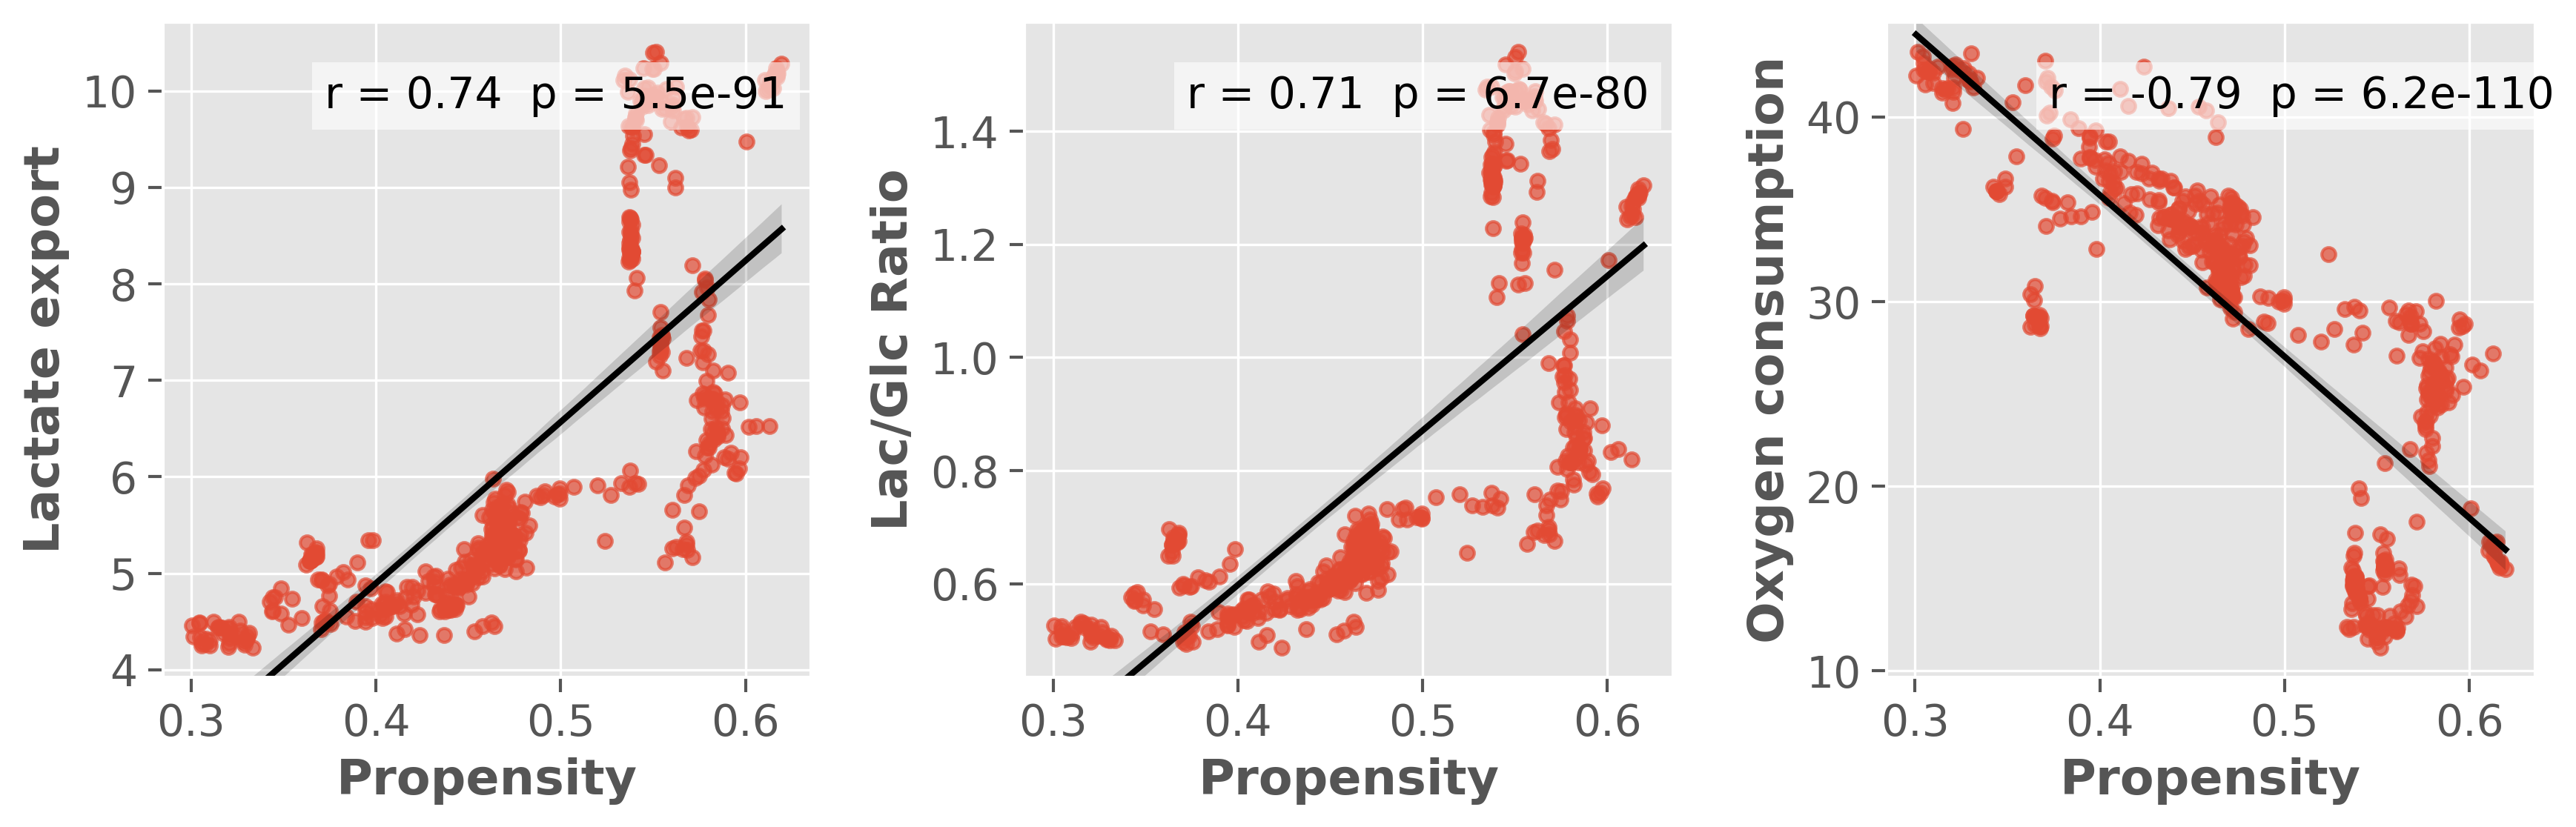

In [17]:
df = tca_metrics_ccle.copy()
o2_col = "O2"

pairs = [
    ("Propensity", "Lac", "Lactate export"),
    ("Propensity", "Lac/Glc", "Lac/Glc Ratio"),
    ("Propensity", o2_col, "Oxygen consumption"),

]
pairs = [(x, y, label) for x, y, label in pairs if (x is not None and y in df.columns)]

if len(pairs) == 0:
    raise ValueError("Nessuna coppia valida trovata. Controlla i nomi colonna del dataframe.")

def _pad(lo, hi, frac=0.05):
    span = hi - lo if hi > lo else 1.0
    pad = frac * span
    return lo - pad, hi + pad

fig, axes = plt.subplots(1, len(pairs), figsize=(12, 4), squeeze=False)
axes = axes.ravel()

for ax, (xcol, ycol, ylabel) in zip(axes, pairs):
    dfp = df[[xcol, ycol]].dropna().copy()
    # Usa il valore assoluto di y
    dfp[ycol] = dfp[ycol].abs()
    
    x, y = dfp[xcol].to_numpy(), dfp[ycol].to_numpy()

    if len(dfp) > 1 and np.std(x) > 0 and np.std(y) > 0:
        r, p = pearsonr(x, y)
    else:
        r, p = np.nan, np.nan

    sns.regplot(
        x=xcol, y=ycol, data=dfp, ax=ax,
        scatter_kws=dict(s=20, alpha=0.7),
        line_kws=dict(lw=2, color='black')
    )

    ax.set_xlim(*_pad(dfp[xcol].min(), dfp[xcol].max()))
    ax.set_ylim(*_pad(dfp[ycol].min(), dfp[ycol].max()))
    ax.set_xlabel("Propensity", fontsize=16, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=16, fontweight='bold')
    ax.tick_params(axis="both", labelsize=14)

    ax.text(
        0.25, 0.92,
        f"r = {r:.2f}  p = {p:.1e}" if np.isfinite(r) else "r = n/a  p = n/a",
        transform=ax.transAxes,
        fontsize=14,
        va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
    )

fig.tight_layout()
fig.savefig("../data/validation_data/ccle/output/plots/corr_propensity_lac_o2_lacglc_abs.png",
            dpi=600, bbox_inches='tight')
plt.show()


## RECON sampling

In [50]:
recon_tca_metrics = pd.read_csv("../data/validation_data/ccle/recon/recon_tca_count.csv", index_col=0)

In [51]:
recon_tca_metrics = recon_tca_metrics[['TCA canonical', 'TCA non canonical']]
recon_tca_metrics.rename(columns={
    'TCA canonical': 'Canonical TCA',
    'TCA non canonical': 'Non Canonical TCA'
}, inplace=True)


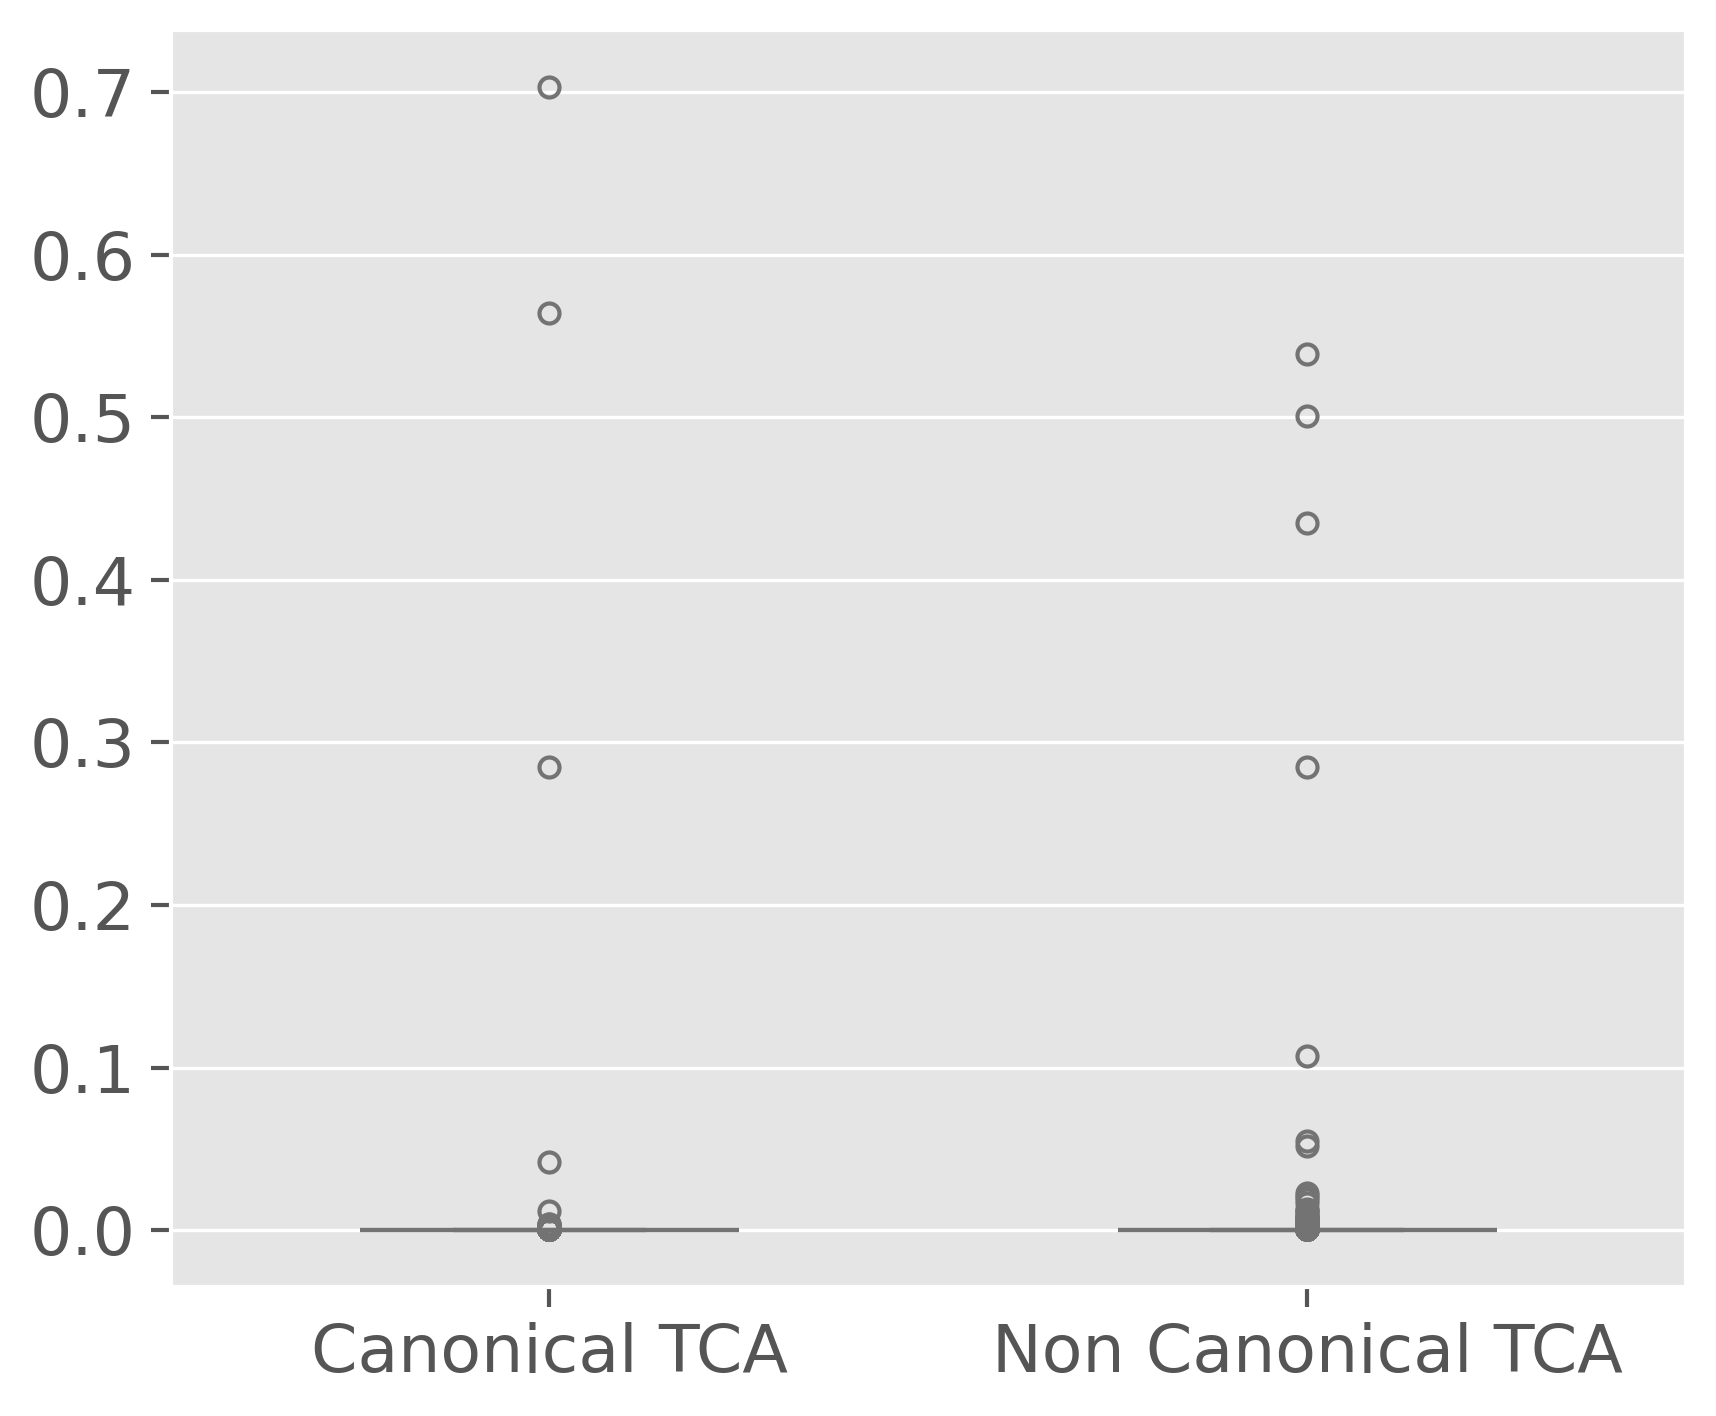

In [56]:
plt.figure(figsize=(6,5))
sns.boxplot(data=recon_tca_metrics, width=0.5, palette="pastel")

plt.tight_layout()
plt.savefig("../data/validation_data/ccle/output/plots/recon_tca_propensity.png",
            dpi=300, bbox_inches='tight')
plt.show()